# 2. Balanced Training â€” Per-Round Models (`scale_pos_weight`)

Trains per-round XGBoost models with `scale_pos_weight` to handle upset class imbalance.  
No synthetic data â€” the loss function is reweighted so misclassifying an upset costs more.

`scale_pos_weight = n_non_upsets / n_upsets` (computed per round).

**Outputs:** `model/round_models_M_balanced_training.joblib`, `model/round_models_W_balanced_training.joblib`

In [49]:
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_absolute_error
from xgboost import XGBClassifier, XGBRegressor

warnings.simplefilter(action='ignore', category=UserWarning)

TRAIN_MIN_SEASON = 2010
TRAIN_MAX_SEASON = 2023
UPSET_SEED_DIFF  = 5

WIN_PARAMS    = dict(learning_rate=0.1, max_depth=4, min_child_weight=4, n_estimators=100)
SPREAD_PARAMS = dict(learning_rate=0.1, max_depth=3, min_child_weight=2, n_estimators=100)
TOTAL_PARAMS  = dict(learning_rate=0.1, max_depth=3, min_child_weight=2, n_estimators=100)

# Matches bracket_rounds_local_2026 exactly
NON_FEATURE_COLS = {'SEASON', 'WIN_INDICATOR', 'L_TEAMID', 'W_TEAMID',
                    'W_SCORE', 'L_SCORE', 'ROUND', 'L_REGION', 'W_REGION'}

ROUND_NAMES = {0: 'Play-In', 1: 'R64', 2: 'R32', 3: 'S16', 4: 'E8', 5: 'FF', 6: 'Champ'}
ROUND_ORDER = ['R64', 'R32', 'S16', 'E8', 'FF', 'Champ']

print('Setup complete.')

Setup complete.


## Load Training Data

In [50]:
def load_and_augment(path):
    """Load original features and W/L augment — exactly matching bracket_rounds_local_2026."""
    df = (
        pd.read_csv(path)
        .rename(columns={
            'WTEAMID': 'W_TEAMID', 'LTEAMID': 'L_TEAMID',
            'WSCORE':  'W_SCORE',  'LSCORE':  'L_SCORE',
        })
    )
    drop_cols = ['W_CTWINS', 'W_AVERAGECTSCORE', 'L_CTWINS', 'L_AVERAGECTSCORE',
                 'W_WLOCN', 'W_WLOCH', 'W_WLOCA', 'L_WLOCN', 'L_WLOCH', 'L_WLOCA']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    train = df[(df.SEASON >= TRAIN_MIN_SEASON) & (df.SEASON <= TRAIN_MAX_SEASON)].copy()

    w_cols = sorted([c for c in train.columns if c.startswith('W_')])
    swapped = train.copy()
    for w in w_cols:
        l = 'L_' + w[2:]
        if l in train.columns:
            swapped[w] = train[l]
            swapped[l] = train[w]

    aug = pd.concat([train, swapped], ignore_index=True)
    aug['WIN_INDICATOR'] = (aug['W_SCORE'] > aug['L_SCORE']).astype(int)
    return aug


aug_m = load_and_augment('data_2026/final_features.csv')
aug_w = load_and_augment('data_2026/final_features_W.csv')

print(f"Men's   training rows: {len(aug_m):,}  |  seasons: {sorted(aug_m.SEASON.unique())}")
print(f"Women's training rows: {len(aug_w):,}  |  seasons: {sorted(aug_w.SEASON.unique())}")

Men's   training rows: 1,708  |  seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Women's training rows: 1,562  |  seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]


C:\Users\joebu\AppData\Local\Temp\ipykernel_8640\2388074853.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aug['WIN_INDICATOR'] = (aug['W_SCORE'] > aug['L_SCORE']).astype(int)
C:\Users\joebu\AppData\Local\Temp\ipykernel_8640\2388074853.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aug['WIN_INDICATOR'] = (aug['W_SCORE'] > aug['L_SCORE']).astype(int)


## Define Feature Columns

In [51]:
feature_cols_m = [c for c in aug_m.columns if c not in NON_FEATURE_COLS]
feature_cols_w = [c for c in aug_w.columns if c not in NON_FEATURE_COLS]

print(f"Men's features: {len(feature_cols_m)} | Women's features: {len(feature_cols_w)}")

Men's features: 164 | Women's features: 157


## Load Original Test Data

In [52]:
def load_test(path):
    df = (
        pd.read_csv(path)
        .rename(columns={
            'WTEAMID': 'W_TEAMID', 'LTEAMID': 'L_TEAMID',
            'WSCORE':  'W_SCORE',  'LSCORE':  'L_SCORE',
        })
    )
    drop_cols = ['W_CTWINS', 'W_AVERAGECTSCORE', 'L_CTWINS', 'L_AVERAGECTSCORE',
                 'W_WLOCN', 'W_WLOCH', 'W_WLOCA', 'L_WLOCN', 'L_WLOCH', 'L_WLOCA']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    df['WIN_INDICATOR'] = 1
    return df[df.SEASON > TRAIN_MAX_SEASON].copy()


test_m = load_test('data_2026/final_features.csv')
test_w = load_test('data_2026/final_features_W.csv')

print(f"Men's   test seasons: {sorted(test_m.SEASON.unique())} | {len(test_m)} games")
print(f"Women's test seasons: {sorted(test_w.SEASON.unique())} | {len(test_w)} games")

Men's   test seasons: [np.int64(2024), np.int64(2025)] | 134 games
Women's test seasons: [np.int64(2024), np.int64(2025)] | 128 games


C:\Users\joebu\AppData\Local\Temp\ipykernel_8640\2923307418.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['WIN_INDICATOR'] = 1


## Train Per-Round Models with `scale_pos_weight`

For each round, compute `scale_pos_weight = n_non_upsets / n_upsets` and pass it to the win classifier.  
Spread and total regressors are unaffected (class imbalance only applies to classification).

In [53]:
def train_per_round(aug_train, feature_cols, label):
    """
    Train 18 per-round XGBoost models (win + spread + total × 6 rounds).
    Win classifier uses scale_pos_weight = n_non_upsets / n_upsets per round.
    An upset row = WIN_INDICATOR=1 AND W_SEED > L_SEED (lower seed won).
    """
    models = {}

    for r in range(1, 7):
        rdf = aug_train[aug_train.ROUND == r]
        if len(rdf) == 0:
            print(f'  [{label}] {ROUND_NAMES[r]}: no data — skipping')
            continue

        feat     = [c for c in feature_cols if c in rdf.columns]
        X        = rdf[feat]
        y_win    = rdf['WIN_INDICATOR']
        y_spread = rdf['W_SCORE'] - rdf['L_SCORE']
        y_total  = rdf['W_SCORE'] + rdf['L_SCORE']

        # Upsets: W won (WIN_IND=1) AND W_SEED > L_SEED (underdog won)
        seed_diff = rdf['W_SEED'] - rdf['L_SEED']
        n_upsets  = ((seed_diff >= UPSET_SEED_DIFF) & (y_win == 1)).sum()
        n_non     = len(rdf) - n_upsets
        spw       = round(n_non / n_upsets, 2) if n_upsets > 0 else 1.0

        win_m = XGBClassifier(eval_metric='logloss', scale_pos_weight=spw, **WIN_PARAMS)
        win_m.fit(X, y_win)

        spr_m = XGBRegressor(eval_metric='rmse', **SPREAD_PARAMS)
        spr_m.fit(X, y_spread)

        tot_m = XGBRegressor(eval_metric='rmse', **TOTAL_PARAMS)
        tot_m.fit(X, y_total)

        models[r] = {'win': win_m, 'spread': spr_m, 'total': tot_m}
        print(f'  [{label}] {ROUND_NAMES[r]}: {len(rdf):,} rows | '
              f'upsets: {n_upsets} ({100*n_upsets/len(rdf):.1f}%) | scale_pos_weight={spw}')

    return models, feat


print("Training Men's per-round models (scale_pos_weight)...")
models_m_bal, feat_m = train_per_round(aug_m, feature_cols_m, 'M')

print("\nTraining Women's per-round models (scale_pos_weight)...")
models_w_bal, feat_w = train_per_round(aug_w, feature_cols_w, 'W')

Training Men's per-round models (scale_pos_weight)...
  [M] R64: 804 rows | upsets: 70 (8.7%) | scale_pos_weight=10.49
  [M] R32: 424 rows | upsets: 44 (10.4%) | scale_pos_weight=8.64
  [M] S16: 190 rows | upsets: 4 (2.1%) | scale_pos_weight=46.5
  [M] E8: 54 rows | upsets: 3 (5.6%) | scale_pos_weight=17.0
  [M] FF: 48 rows | upsets: 3 (6.2%) | scale_pos_weight=15.0
  [M] Champ: 98 rows | upsets: 6 (6.1%) | scale_pos_weight=15.33

Training Women's per-round models (scale_pos_weight)...
  [W] R64: 596 rows | upsets: 22 (3.7%) | scale_pos_weight=26.09
  [W] R32: 510 rows | upsets: 29 (5.7%) | scale_pos_weight=16.59
  [W] S16: 146 rows | upsets: 3 (2.1%) | scale_pos_weight=47.67
  [W] E8: 112 rows | upsets: 0 (0.0%) | scale_pos_weight=1.0
  [W] FF: 18 rows | upsets: 0 (0.0%) | scale_pos_weight=1.0
  [W] Champ: 164 rows | upsets: 5 (3.0%) | scale_pos_weight=31.8


## Save Balanced Training Models

In [54]:
# Save in same format as original: (models_dict, feature_cols_list)
joblib.dump((models_m_bal, feat_m), 'model/round_models_M_balanced_training.joblib')
joblib.dump((models_w_bal, feat_w), 'model/round_models_W_balanced_training.joblib')

print('Saved:')
print('  model/round_models_M_balanced_training.joblib')
print('  model/round_models_W_balanced_training.joblib')

Saved:
  model/round_models_M_balanced_training.joblib
  model/round_models_W_balanced_training.joblib


## Load Original Models for Comparison

In [55]:
orig_m_data = joblib.load('model/round_models_M.joblib')
orig_w_data = joblib.load('model/round_models_W.joblib')

# Format: (models_dict, feature_cols_list)
models_m_orig, feat_m_orig = orig_m_data[0], orig_m_data[1]
models_w_orig, feat_w_orig = orig_w_data[0], orig_w_data[1]

print(f'Original Men\'s   models loaded: rounds {sorted(models_m_orig.keys())}')
print(f'Original Women\'s models loaded: rounds {sorted(models_w_orig.keys())}')

Original Men's   models loaded: rounds [0, 1, 2, 3, 4, 5, 6]
Original Women's models loaded: rounds [0, 1, 2, 3, 4, 5, 6]


## Evaluate Both Models on 2024–2025 Test Set

Evaluation convention matches bracket simulation: **W = lower seed (favorite), L = higher seed (underdog)**.  
- `WIN_INDICATOR = 1` → favorite won (expected)  
- `WIN_INDICATOR = 0` → underdog won (upset)  

Overall accuracy measures how often the model picks the actual winner. Upset accuracy measures how often it correctly identifies upset games.

In [56]:
def swap_wl(df):
    out = df.copy()
    w_cols = sorted([c for c in df.columns if c.startswith('W_')])
    for w in w_cols:
        l = 'L_' + w[2:]
        if l in df.columns:
            out[w] = df[l]; out[l] = df[w]
    return out


def make_fair_test(test_orig):
    """
    Standardize orientation to match bracket simulation:
      W = lower seed (favorite), L = higher seed (underdog)
    WIN_INDICATOR = 1 if the favorite won, 0 if upset.
    Games where seeds are equal (play-in) are left as-is.
    """
    needs_swap = test_orig['W_SEED'] > test_orig['L_SEED']
    fair = pd.concat([
        test_orig[~needs_swap],
        swap_wl(test_orig[needs_swap]),
    ], ignore_index=True)
    fair['WIN_INDICATOR'] = (fair['W_SCORE'] > fair['L_SCORE']).astype(int)
    fair['ACTUAL_SPREAD'] = fair['W_SCORE'] - fair['L_SCORE']
    fair['ACTUAL_TOTAL']  = fair['W_SCORE'] + fair['L_SCORE']
    fair['SEED_DIFF']     = fair['W_SEED'] - fair['L_SEED']
    return fair


def eval_models(test_orig, feature_cols, models_dict, model_label, gender_label):
    """Evaluate per-round models using lower-seed-as-W convention."""
    test_fair = make_fair_test(test_orig)

    rows = []
    for r in sorted(models_dict.keys()):
        if r == 0:
            continue
        test_r = test_fair[test_fair.ROUND == r].reset_index(drop=True)
        if len(test_r) == 0:
            continue

        mdl  = models_dict[r]
        feat = [c for c in feature_cols if c in test_r.columns]
        X    = test_r[feat]

        win_preds    = mdl['win'].predict(X)
        spread_preds = mdl['spread'].predict(X)
        total_preds  = mdl['total'].predict(X)

        win_acc    = accuracy_score(test_r['WIN_INDICATOR'], win_preds)
        spread_mae = mean_absolute_error(test_r['ACTUAL_SPREAD'], spread_preds)
        total_mae  = mean_absolute_error(test_r['ACTUAL_TOTAL'],  total_preds)

        # Upset games: WIN_INDICATOR=0 means the underdog (L team) actually won
        up_mask  = test_r['WIN_INDICATOR'] == 0
        n_upsets = up_mask.sum()
        # Correct on an upset = predicting 0 (underdog wins)
        upset_acc = float(np.mean(win_preds[up_mask.values] == 0)) if n_upsets > 0 else float('nan')

        rows.append({
            'Gender':        gender_label,
            'Model':         model_label,
            'Round':         ROUND_NAMES.get(r, f'R{r}'),
            'N_Games':       len(test_r),
            'N_Upsets':      n_upsets,
            'Win_Acc':       round(win_acc, 4),
            'Spread_MAE':    round(spread_mae, 2),
            'Total_MAE':     round(total_mae, 2),
            'Upset_Win_Acc': round(upset_acc, 4) if not pd.isna(upset_acc) else None,
        })
    return rows


rows_m_orig = eval_models(test_m, feat_m_orig, models_m_orig, 'Original', "Men's")
rows_m_bal  = eval_models(test_m, feat_m,      models_m_bal,  'Balanced', "Men's")
rows_w_orig = eval_models(test_w, feat_w_orig, models_w_orig, 'Original', "Women's")
rows_w_bal  = eval_models(test_w, feat_w,      models_w_bal,  'Balanced', "Women's")

results_df = pd.DataFrame(rows_m_orig + rows_m_bal + rows_w_orig + rows_w_bal)
print('Evaluation complete. (W = lower seed / favorite)')

C:\Users\joebu\AppData\Local\Temp\ipykernel_8640\3910038.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fair['ACTUAL_SPREAD'] = fair['W_SCORE'] - fair['L_SCORE']
C:\Users\joebu\AppData\Local\Temp\ipykernel_8640\3910038.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fair['ACTUAL_TOTAL']  = fair['W_SCORE'] + fair['L_SCORE']
C:\Users\joebu\AppData\Local\Temp\ipykernel_8640\3910038.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

Evaluation complete. (W = lower seed / favorite)


## Results: Men's â€” Original vs Balanced

In [57]:
def display_comparison(results_df, gender):
    df_g = results_df[results_df['Gender'] == gender].copy()
    df_g['Round'] = pd.Categorical(df_g['Round'], categories=ROUND_ORDER, ordered=True)
    df_g = df_g.sort_values(['Round', 'Model'])

    # Side-by-side per round
    print(f"\n{'='*80}")
    print(f"{gender} Tournament â€” Original vs Balanced Training (2024â€“2025 Test Set)")
    print(f"{'='*80}")
    print(f"{'Round':<12} {'Model':<10} {'Games':>6} {'Upsets':>7} "
          f"{'Win Acc':>8} {'Spd MAE':>8} {'Tot MAE':>8} {'UpstAcc':>8}")
    print('-' * 80)

    deltas = []
    for rnd in ROUND_ORDER:
        rdf = df_g[df_g['Round'] == rnd]
        for _, row in rdf.iterrows():
            upst = f"{row['Upset_Win_Acc']:.4f}" if row['Upset_Win_Acc'] is not None else '   n/a'
            print(f"{rnd:<12} {row['Model']:<10} {row['N_Games']:>6} {row['N_Upsets']:>7} "
                  f"{row['Win_Acc']:>8.4f} {row['Spread_MAE']:>8.2f} "
                  f"{row['Total_MAE']:>8.2f} {upst:>8}")

        if len(rdf) == 2:
            orig = rdf[rdf.Model == 'Original'].iloc[0]
            bal  = rdf[rdf.Model == 'Balanced'].iloc[0]
            d_win = bal['Win_Acc'] - orig['Win_Acc']
            d_spr = bal['Spread_MAE'] - orig['Spread_MAE']
            d_tot = bal['Total_MAE'] - orig['Total_MAE']
            d_up  = (bal['Upset_Win_Acc'] or 0) - (orig['Upset_Win_Acc'] or 0)
            sign  = lambda v: '+' if v >= 0 else ''
            print(f"{'  Delta':<22} {'':>6} {'':>7} "
                  f"{sign(d_win)}{d_win:>+7.4f} {sign(d_spr)}{d_spr:>+7.2f} "
                  f"{sign(d_tot)}{d_tot:>+7.2f} {sign(d_up)}{d_up:>+7.4f}")
            deltas.append({'Round': rnd, 'dWin': d_win, 'dSpr': d_spr, 'dTot': d_tot, 'dUp': d_up})
        print()

    # Overall means
    print('\nOverall means:')
    for model in ['Original', 'Balanced']:
        sub = df_g[df_g.Model == model]
        print(f"  {model}: Win Acc={sub['Win_Acc'].mean():.4f} | "
              f"Spread MAE={sub['Spread_MAE'].mean():.2f} | "
              f"Total MAE={sub['Total_MAE'].mean():.2f}")

    return deltas


deltas_m = display_comparison(results_df, "Men's")


Men's Tournament â€” Original vs Balanced Training (2024â€“2025 Test Set)
Round        Model       Games  Upsets  Win Acc  Spd MAE  Tot MAE  UpstAcc
--------------------------------------------------------------------------------
R64          Balanced       64      18   0.7031     9.77    12.25   0.0000
R64          Original       64      18   0.9844     5.94     6.51   0.9444
  Delta                               -0.2813 +  +3.83 +  +5.74 -0.9444

R32          Balanced       32       6   0.8125    10.22    14.49   0.0000
R32          Original       32       6   1.0000     5.30     5.87   1.0000
  Delta                               -0.1875 +  +4.92 +  +8.62 -1.0000

S16          Balanced       16       5   0.6875     9.89    20.16   0.0000
S16          Original       16       5   1.0000     1.29     3.30   1.0000
  Delta                               -0.3125 +  +8.60 + +16.86 -1.0000

E8           Balanced        4       0   1.0000     9.46    16.31      nan
E8           Original    

## Results: Women's â€” Original vs Balanced

In [58]:
deltas_w = display_comparison(results_df, "Women's")


Women's Tournament â€” Original vs Balanced Training (2024â€“2025 Test Set)
Round        Model       Games  Upsets  Win Acc  Spd MAE  Tot MAE  UpstAcc
--------------------------------------------------------------------------------
R64          Balanced       63       5   0.9048    12.07    13.04   0.0000
R64          Original       63       5   1.0000     5.64     7.20   1.0000
  Delta                               -0.0952 +  +6.43 +  +5.84 -1.0000

R32          Balanced       31       6   0.8387    10.12    14.43   0.1667
R32          Original       31       6   1.0000     4.42     6.61   1.0000
  Delta                               -0.1613 +  +5.70 +  +7.82 -0.8333

S16          Balanced       15       4   0.7333     9.45    12.55   0.0000
S16          Original       15       4   1.0000     1.59     1.67   1.0000
  Delta                               -0.2667 +  +7.86 + +10.88 -1.0000

E8           Balanced        7       3   0.7143    10.39    21.26   0.6667
E8           Original  

## Visualization: Win Accuracy by Round â€” Original vs Balanced

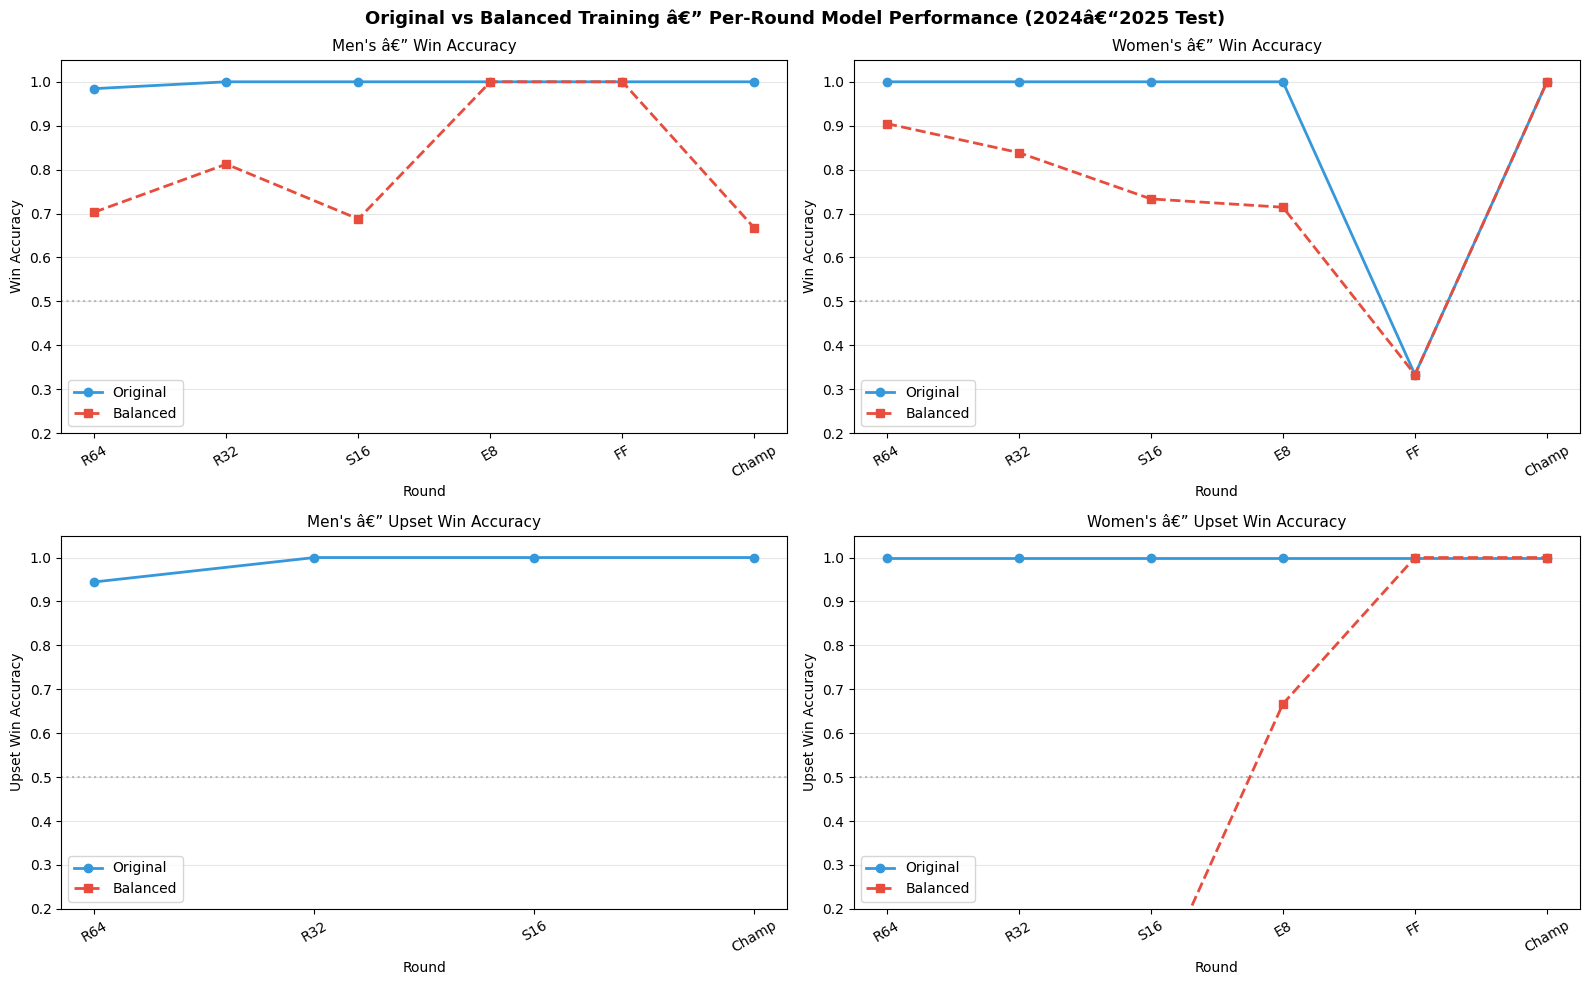

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = {'Original': '#3498db', 'Balanced': '#e74c3c'}
markers = {'Original': 'o', 'Balanced': 's'}

metric_pairs = [
    ('Win_Acc',       'Win Accuracy',       axes[0]),
    ('Upset_Win_Acc', 'Upset Pred Accuracy', axes[1]),
]

for (metric, ylabel, axrow), gender in [
    (metric_pairs[0], "Men's"), (metric_pairs[0], "Women's"),
    (metric_pairs[1], "Men's"), (metric_pairs[1], "Women's")
]:
    pass  # build below properly


plot_specs = [
    (axes[0, 0], "Men's",   'Win_Acc',       'Win Accuracy'),
    (axes[0, 1], "Women's", 'Win_Acc',       'Win Accuracy'),
    (axes[1, 0], "Men's",   'Upset_Win_Acc', 'Upset Win Accuracy'),
    (axes[1, 1], "Women's", 'Upset_Win_Acc', 'Upset Win Accuracy'),
]

for ax, gender, metric, ylabel in plot_specs:
    df_g = results_df[(results_df['Gender'] == gender) &
                      results_df[metric].notna()].copy()
    df_g['Round'] = pd.Categorical(df_g['Round'], categories=ROUND_ORDER, ordered=True)
    df_g = df_g.sort_values('Round')

    for model in ['Original', 'Balanced']:
        sub = df_g[df_g.Model == model]
        ax.plot(sub['Round'].astype(str), sub[metric],
                marker=markers[model], color=colors[model],
                linestyle='-' if model == 'Original' else '--',
                label=model, linewidth=2)

    ax.set_title(f'{gender} â€” {ylabel}', fontsize=11)
    ax.set_xlabel('Round')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0.2, 1.05)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.legend()
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Original vs Balanced Training â€” Per-Round Model Performance (2024â€“2025 Test)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary Table

In [60]:
summary_rows = []
for gender in ["Men's", "Women's"]:
    for model in ['Original', 'Balanced']:
        sub = results_df[(results_df.Gender == gender) & (results_df.Model == model)]
        summary_rows.append({
            'Gender':     gender,
            'Training':   model,
            'Win Acc':    f"{sub['Win_Acc'].mean():.4f}",
            'Spread MAE': f"{sub['Spread_MAE'].mean():.2f}",
            'Total MAE':  f"{sub['Total_MAE'].mean():.2f}",
            'Upset Acc':  f"{sub['Upset_Win_Acc'].dropna().mean():.4f}" if sub['Upset_Win_Acc'].notna().any() else 'n/a',
        })

summary_df = pd.DataFrame(summary_rows)
print('\nOverall Performance Summary â€” Original vs Balanced Training')
print('(Averaged across all rounds on 2024â€“2025 test set)')
display(summary_df)

print('\nModels saved at:')
print('  model/round_models_M_balanced_training.joblib')
print('  model/round_models_W_balanced_training.joblib')


Overall Performance Summary â€” Original vs Balanced Training
(Averaged across all rounds on 2024â€“2025 test set)


,Gender,Training,Win Acc,Spread MAE,Total MAE,Upset Acc
0,Men's,Original,0.9974,2.36,2.84,0.9861
1,Men's,Balanced,0.8116,9.88,15.55,0.0000
2,Women's,Original,0.8889,2.48,2.98,1.0000
3,Women's,Balanced,0.7541,13.86,13.43,0.4722



Models saved at:
  model/round_models_M_balanced_training.joblib
  model/round_models_W_balanced_training.joblib


## Rolling Leave-One-Season-Out Evaluation (Last 10 Seasons)

For each of the last 10 available seasons, train on **all prior seasons** and test on that season alone.  
This gives a realistic picture of how the model would have performed each year without data leakage.

- **Test seasons**: 2015–2025 (skipping 2020 — no tournament)
- **Training**: all seasons before the test season (starting from 2003)
- **Evaluation convention**: W = lower seed (favorite), `WIN_INDICATOR=0` = upset

In [ ]:
def load_all_seasons(path):
    """Load full dataset without season filtering."""
    df = (
        pd.read_csv(path)
        .rename(columns={
            'WTEAMID': 'W_TEAMID', 'LTEAMID': 'L_TEAMID',
            'WSCORE':  'W_SCORE',  'LSCORE':  'L_SCORE',
        })
    )
    drop_cols = ['W_CTWINS', 'W_AVERAGECTSCORE', 'L_CTWINS', 'L_AVERAGECTSCORE',
                 'W_WLOCN', 'W_WLOCH', 'W_WLOCA', 'L_WLOCN', 'L_WLOCH', 'L_WLOCA']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    return df


df_m_all = load_all_seasons('data_2026/final_features.csv')
df_w_all = load_all_seasons('data_2026/final_features_W.csv')

all_seasons_m = sorted(df_m_all.SEASON.unique())
all_seasons_w = sorted(df_w_all.SEASON.unique())

# Last 10 test-eligible seasons (skip 2020 — no tournament)
test_seasons = sorted(all_seasons_m)[-10:]
print(f"All available seasons (M): {all_seasons_m}")
print(f"Rolling test seasons:      {test_seasons}")

In [ ]:
def augment_for_seasons(df, train_seasons):
    """W/L augment a specific set of training seasons."""
    train = df[df.SEASON.isin(train_seasons)].copy()
    w_cols = sorted([c for c in train.columns if c.startswith('W_')])
    swapped = train.copy()
    for w in w_cols:
        l = 'L_' + w[2:]
        if l in train.columns:
            swapped[w] = train[l]
            swapped[l] = train[w]
    aug = pd.concat([train, swapped], ignore_index=True)
    aug['WIN_INDICATOR'] = (aug['W_SCORE'] > aug['L_SCORE']).astype(int)
    return aug


def train_per_round_quiet(aug_train, feature_cols):
    """Same as train_per_round but silent — returns (models_dict, feat_list)."""
    models = {}
    for r in range(1, 7):
        rdf = aug_train[aug_train.ROUND == r]
        if len(rdf) == 0:
            continue
        feat     = [c for c in feature_cols if c in rdf.columns]
        X        = rdf[feat]
        y_win    = rdf['WIN_INDICATOR']
        y_spread = rdf['W_SCORE'] - rdf['L_SCORE']
        y_total  = rdf['W_SCORE'] + rdf['L_SCORE']

        seed_diff = rdf['W_SEED'] - rdf['L_SEED']
        n_upsets  = ((seed_diff >= UPSET_SEED_DIFF) & (y_win == 1)).sum()
        n_non     = len(rdf) - n_upsets
        spw       = round(n_non / n_upsets, 2) if n_upsets > 0 else 1.0

        win_m = XGBClassifier(eval_metric='logloss', scale_pos_weight=spw, **WIN_PARAMS)
        win_m.fit(X, y_win)
        spr_m = XGBRegressor(eval_metric='rmse', **SPREAD_PARAMS)
        spr_m.fit(X, y_spread)
        tot_m = XGBRegressor(eval_metric='rmse', **TOTAL_PARAMS)
        tot_m.fit(X, y_total)

        models[r] = {'win': win_m, 'spread': spr_m, 'total': tot_m}
    return models, feat


def rolling_evaluation(df_all, gender_label, test_seasons):
    """
    For each test season, train on all prior seasons and evaluate on that season.
    Returns a DataFrame with per-season aggregate metrics.
    """
    season_rows = []

    for test_season in test_seasons:
        train_seasons = [s for s in sorted(df_all.SEASON.unique()) if s < test_season]
        if len(train_seasons) < 5:
            print(f"  [{gender_label}] {test_season}: skipping — only {len(train_seasons)} training seasons")
            continue

        aug = augment_for_seasons(df_all, train_seasons)
        feat_cols = [c for c in aug.columns if c not in NON_FEATURE_COLS]
        models_r, feat = train_per_round_quiet(aug, feat_cols)

        # Build test set: raw CSV rows for this season (W = actual winner in raw data)
        test_orig = df_all[df_all.SEASON == test_season].copy()
        test_orig['WIN_INDICATOR'] = 1  # placeholder — overwritten in make_fair_test

        # Evaluate using lower-seed-as-W convention
        eval_rows = eval_models(test_orig, feat, models_r, str(test_season), gender_label)

        # Aggregate across rounds for this season
        if not eval_rows:
            continue
        edf = pd.DataFrame(eval_rows)
        n_upsets = edf['N_Upsets'].sum()
        upset_acc = (
            edf.dropna(subset=['Upset_Win_Acc'])
               .apply(lambda r: r['Upset_Win_Acc'] * r['N_Upsets'], axis=1).sum()
            / n_upsets if n_upsets > 0 else float('nan')
        )

        season_rows.append({
            'Gender':         gender_label,
            'Season':         test_season,
            'Train_Seasons':  len(train_seasons),
            'N_Games':        edf['N_Games'].sum(),
            'N_Upsets':       n_upsets,
            'Win_Acc':        round(edf['Win_Acc'].mean(), 4),
            'Spread_MAE':     round(edf['Spread_MAE'].mean(), 2),
            'Total_MAE':      round(edf['Total_MAE'].mean(), 2),
            'Upset_Win_Acc':  round(upset_acc, 4) if not pd.isna(upset_acc) else None,
        })
        ua_str = f"{upset_acc:.4f}" if not pd.isna(upset_acc) else 'n/a'
        print(f"  [{gender_label}] {test_season} — Win Acc: {season_rows[-1]['Win_Acc']:.4f} | "
              f"Upsets: {n_upsets} | Upset Acc: {ua_str}")

    return pd.DataFrame(season_rows)


print("Running rolling evaluation — Men's (10 seasons)...")
roll_m = rolling_evaluation(df_m_all, "Men's", test_seasons)

print("\nRunning rolling evaluation — Women's (10 seasons)...")
all_seasons_w_list = sorted(df_w_all.SEASON.unique())
test_seasons_w = sorted(all_seasons_w_list)[-10:]
roll_w = rolling_evaluation(df_w_all, "Women's", test_seasons_w)

rolling_df = pd.concat([roll_m, roll_w], ignore_index=True)
print("\nDone.")

In [ ]:
print("Rolling Leave-One-Season-Out Results")
print("=" * 80)

for gender in ["Men's", "Women's"]:
    rdf = rolling_df[rolling_df.Gender == gender].copy()
    print(f"\n{gender}")
    print(f"{'Season':>8} {'Train Yrs':>10} {'Games':>7} {'Upsets':>7} "
          f"{'Win Acc':>9} {'Spd MAE':>8} {'Tot MAE':>8} {'UpstAcc':>9}")
    print('-' * 80)
    for _, row in rdf.iterrows():
        ua = f"{row['Upset_Win_Acc']:.4f}" if row['Upset_Win_Acc'] is not None else '     n/a'
        print(f"{int(row.Season):>8} {int(row.Train_Seasons):>10} {int(row.N_Games):>7} "
              f"{int(row.N_Upsets):>7} {row.Win_Acc:>9.4f} {row.Spread_MAE:>8.2f} "
              f"{row.Total_MAE:>8.2f} {ua:>9}")
    avg_win = rdf.Win_Acc.mean()
    avg_spr = rdf.Spread_MAE.mean()
    avg_tot = rdf.Total_MAE.mean()
    avg_up  = rdf.Upset_Win_Acc.dropna().mean()
    print(f"{'AVERAGE':>8} {'':>10} {'':>7} {'':>7} {avg_win:>9.4f} {avg_spr:>8.2f} "
          f"{avg_tot:>8.2f} {avg_up:>9.4f}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
palette = {"Men's": '#3498db', "Women's": '#e74c3c'}

metrics = [
    ('Win_Acc',       'Win Accuracy',       (0, 0), (0.4, 1.05)),
    ('Upset_Win_Acc', 'Upset Win Accuracy', (0, 1), (0.0, 1.05)),
    ('Spread_MAE',    'Spread MAE (pts)',   (1, 0), None),
    ('Total_MAE',     'Total MAE (pts)',    (1, 1), None),
]

for metric, ylabel, (ri, ci), ylim in metrics:
    ax = axes[ri][ci]
    for gender in ["Men's", "Women's"]:
        sub = rolling_df[(rolling_df.Gender == gender) & rolling_df[metric].notna()]
        ax.plot(sub.Season, sub[metric],
                marker='o', color=palette[gender],
                label=gender, linewidth=2)
        # Annotate each point
        for _, row in sub.iterrows():
            ax.annotate(f"{row[metric]:.2f}", (row.Season, row[metric]),
                        textcoords='offset points', xytext=(0, 6),
                        fontsize=7, ha='center', color=palette[gender])

    if ylim:
        ax.set_ylim(*ylim)
    if ri == 0:
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4, label='Random baseline')
    ax.set_title(ylabel, fontsize=11)
    ax.set_xlabel('Test Season')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Rolling Leave-One-Season-Out Evaluation — Per-Season Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()